In [1]:
# load labraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier

import xgboost as xgb

from scipy.stats import zscore
from statsmodels.stats.weightstats import ztest

import shap

In [2]:
# load dataset
df = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)

In [3]:
#print shape and head of data
print(df.shape)
df.head()

(2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# run info, describe, and missing value
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_end_date                             2249784
hardship_start_date                           2249784
hardship_type                                 2249784
                                               ...   
policy_code                                        33
revol_bal                                          33
fico_range_high                                    33
fico_range_low                                     33
id                                                  0
Length: 151, dtype: int64

In [5]:
# drop missing values
missing_ratio = df.isnull().mean()
df = df.drop(missing_ratio[missing_ratio > 0.3].index, axis=1)

df = df.drop(['id', 'member_id', 'url', 'desc'], axis=1, errors='ignore')

In [6]:
# filter rows
filtered_df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# filter DataFrame
filtered_df['loan_status'] = filtered_df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

filtered_df['loan_status'].value_counts()

loan_status
0    1076751
1     268559
Name: count, dtype: int64

In [7]:
# Sample 300,000 rows to reduce memory usage
sampled_df = filtered_df.sample(n=300000, random_state=42)

# Reset index just in case
sampled_df = sampled_df.reset_index(drop=True)

# Redefine X and y from the sampled data
X = sampled_df.drop('loan_status', axis=1)
y = sampled_df['loan_status']


In [8]:
# Check the class distribution in y
print(y.value_counts())
print("\nPercentage:\n", y.value_counts(normalize=True) * 100)

loan_status
0    240398
1     59602
Name: count, dtype: int64

Percentage:
 loan_status
0    80.132667
1    19.867333
Name: proportion, dtype: float64


In [9]:
# check for duplicates
print("Duplicate rows:", sampled_df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(sampled_df.shape)
sampled_df.head()

(300000, 91)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,8000.0,8000.0,8000.0,36 months,7.69,249.55,A,A4,eligibility Assistant,1 year,...,0.0,0.0,0.0,222635.0,22789.0,2200.0,23735.0,N,Cash,N
1,12000.0,12000.0,12000.0,36 months,15.05,416.28,C,C4,Machine Operator,< 1 year,...,66.7,0.0,0.0,29154.0,24595.0,4700.0,21654.0,N,Cash,N
2,8000.0,8000.0,7975.0,36 months,12.99,269.52,C,C1,PCA,2 years,...,60.0,1.0,0.0,27275.0,22763.0,6500.0,18775.0,N,Cash,N
3,5000.0,5000.0,5000.0,36 months,11.49,164.86,B,B5,NaN,NaN,...,75.0,0.0,0.0,16500.0,11350.0,15700.0,0.0,N,Cash,N
4,30800.0,30800.0,30800.0,36 months,11.99,1022.86,C,C1,Engineer,10+ years,...,85.7,0.0,0.0,252826.0,77136.0,47200.0,52489.0,N,Cash,N


Z-Test Results (Defaulters vs Fully Paid):

annual_inc: z-stat = 23.14, p-value = 0.0000
loan_amnt: z-stat = -34.88, p-value = 0.0000
int_rate: z-stat = -147.17, p-value = 0.0000
installment: z-stat = -26.94, p-value = 0.0000


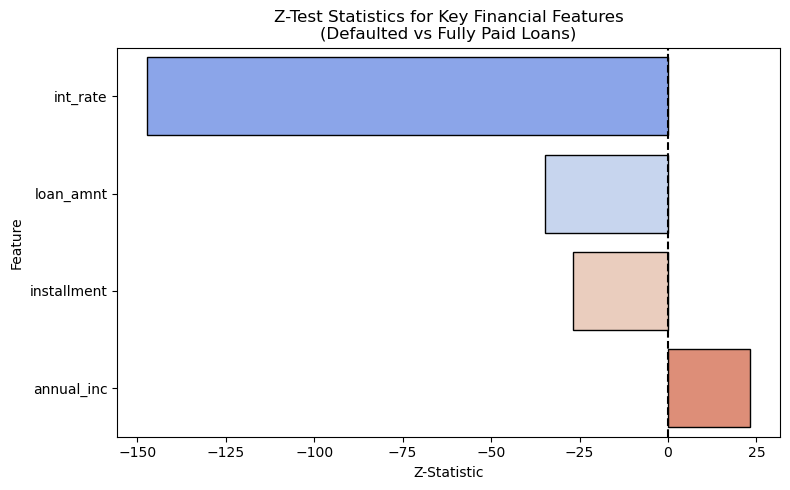

In [11]:

# Define features to test
features_to_test = ['annual_inc', 'loan_amnt', 'int_rate', 'installment']

# Store results
z_stats = []
p_values = []

print("Z-Test Results (Defaulters vs Fully Paid):\n")
for feature in features_to_test:
    group0 = sampled_df[sampled_df['loan_status'] == 0][feature].dropna()
    group1 = sampled_df[sampled_df['loan_status'] == 1][feature].dropna()
    
    z_stat, p_val = ztest(group0, group1)
    z_stats.append(z_stat)
    p_values.append(p_val)
    
    print(f"{feature}: z-stat = {z_stat:.2f}, p-value = {p_val:.4f}")

# Create dataframe for plotting
z_test_df = pd.DataFrame({
    "Feature": features_to_test,
    "Z-Statistic": z_stats,
    "P-Value": p_values
})

# Sort features by absolute Z-value for better visual order (optional)
z_test_df = z_test_df.sort_values(by="Z-Statistic", key=lambda x: abs(x), ascending=False)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=z_test_df, y="Feature", x="Z-Statistic", palette="coolwarm", edgecolor="black")
plt.axvline(0, color='black', linestyle='--')
plt.title("Z-Test Statistics for Key Financial Features\n(Defaulted vs Fully Paid Loans)")
plt.xlabel("Z-Statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [14]:
# Define features and run Z-tests
features_to_test = ['annual_inc', 'loan_amnt', 'int_rate', 'installment']
z_stats = []
p_values = []
significance = []

for feature in features_to_test:
    group0 = sampled_df[sampled_df['loan_status'] == 0][feature].dropna()
    group1 = sampled_df[sampled_df['loan_status'] == 1][feature].dropna()
    
    z_stat, p_val = ztest(group0, group1)
    z_stats.append(round(z_stat, 2))
    p_values.append(p_val)

    # Add significance stars
    if p_val < 0.001:
        significance.append("***")
    elif p_val < 0.01:
        significance.append("**")
    elif p_val < 0.05:
        significance.append("*")
    else:
        significance.append("")

# Create results table
z_test_table = pd.DataFrame({
    "Feature": features_to_test,
    "Z-Statistic": z_stats,
    "P-Value": [f"{p:.4f}" for p in p_values],
    "Significance": significance
})

# Display the table
print("\nZ-Test Summary Table:")
print(z_test_table.to_string(index=False))




Z-Test Summary Table:
    Feature  Z-Statistic P-Value Significance
 annual_inc        23.14  0.0000          ***
  loan_amnt       -34.88  0.0000          ***
   int_rate      -147.17  0.0000          ***
installment       -26.94  0.0000          ***


In [15]:
# Drop leakage-related columns 
leak_cols = [
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_credit_pull_d', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'out_prncp', 'out_prncp_inv', 'funded_amnt', 'funded_amnt_inv',
    'issue_d'
]
X = X.drop(columns=leak_cols, errors='ignore')


In [16]:
# Handle missing numeric values using median
X = X.fillna(X.median(numeric_only=True))

# Drop high-cardinality categorical columns 
X = X.drop(['emp_title', 'title', 'zip_code'], axis=1, errors='ignore')

# Identify and one-hot encode remaining categorical variables
cat_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (240000, 873)
Test shape: (60000, 873)


In [17]:
# using SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts())


Class distribution after SMOTE:
loan_status
1    192318
0    192318
Name: count, dtype: int64


In [18]:
# Apply PCA to keep 95% variance
pca = PCA(n_components=0.95, random_state=42)

# resampled input
X_train_pca = pca.fit_transform(X_train_resampled)  
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_resampled.shape)
print("PCA shape:", X_train_pca.shape)



Original shape: (384636, 873)
PCA shape: (384636, 764)


In [19]:
# Train Logistic Regression on PCA-transformed data
logreg_pca = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca.fit(X_train_pca, y_train_resampled)

# Predict and evaluate
y_pred_pca = logreg_pca.predict(X_test_pca)
y_proba_pca = logreg_pca.predict_proba(X_test_pca)[:, 1]

print("Classification Report (with PCA):")
print(classification_report(y_test, y_pred_pca))
print("ROC-AUC Score (with PCA):", roc_auc_score(y_test, y_proba_pca))


Classification Report (with PCA):
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     48080
           1       0.78      0.93      0.84     11920

    accuracy                           0.93     60000
   macro avg       0.88      0.93      0.90     60000
weighted avg       0.94      0.93      0.93     60000

ROC-AUC Score (with PCA): 0.978715186657584


In [20]:
# Train the model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate 
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))



Confusion Matrix:
 [[45109  2971]
 [  760 11160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     48080
           1       0.79      0.94      0.86     11920

    accuracy                           0.94     60000
   macro avg       0.89      0.94      0.91     60000
weighted avg       0.94      0.94      0.94     60000

ROC-AUC Score: 0.9828292226881373


In [21]:
# Checking for data leakage 
scores = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", scores)
print("Mean AUC:", scores.mean())

CV ROC-AUC Scores: [0.98209578 0.98242318 0.98266428 0.98342479 0.98226943]
Mean AUC: 0.9825754922104706


In [22]:
# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97     48080
           1       0.89      0.84      0.87     11920

    accuracy                           0.95     60000
   macro avg       0.93      0.91      0.92     60000
weighted avg       0.95      0.95      0.95     60000

ROC-AUC Score: 0.979083775014238


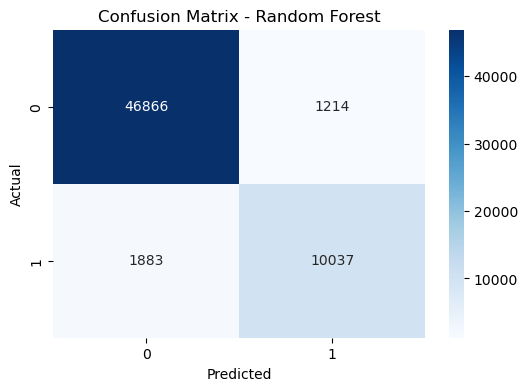

In [23]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

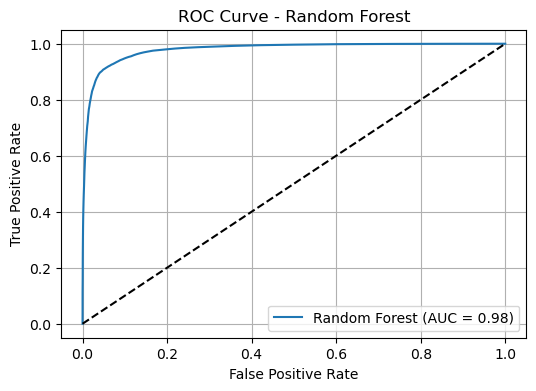

In [24]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_rf)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

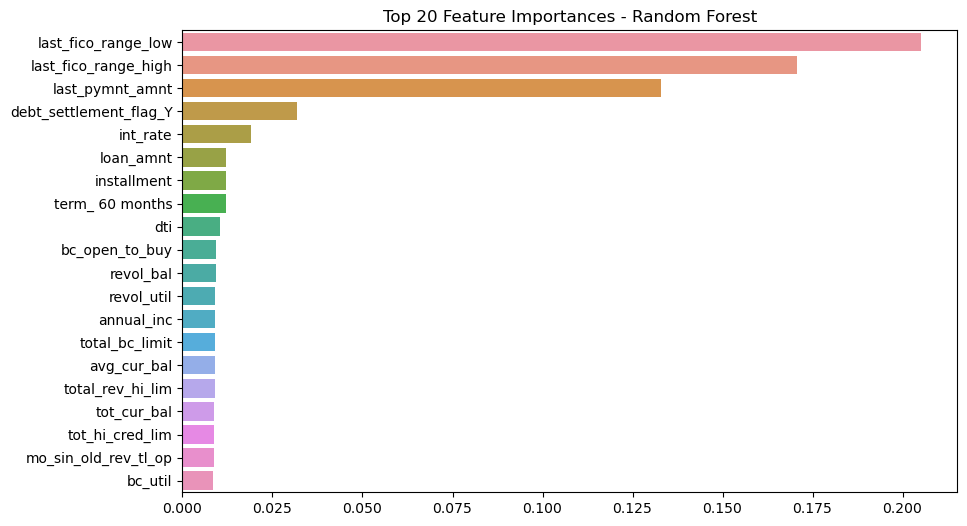

In [25]:
# Plot Feature Importance (Top 20)
importances = rf_model.feature_importances_
indices = importances.argsort()[-20:][::-1]
feature_names = X.columns[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names)
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

In [26]:
# Initialise and fit the model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

C:\Users\ilham_7t2frur\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:00:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
# Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test_scaled) 
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1] 

print("Classification Report - XGBoost:\n", classification_report(y_test, y_pred_xgb)) 
print("Confusion Matrix - XGBoost:\n", confusion_matrix(y_test, y_pred_xgb)) 
print("ROC-AUC Score - XGBoost:", roc_auc_score(y_test, y_proba_xgb)) 

Classification Report - XGBoost:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     48080
           1       0.89      0.90      0.89     11920

    accuracy                           0.96     60000
   macro avg       0.93      0.94      0.93     60000
weighted avg       0.96      0.96      0.96     60000

Confusion Matrix - XGBoost:
 [[46750  1330]
 [ 1212 10708]]
ROC-AUC Score - XGBoost: 0.9894352288970284


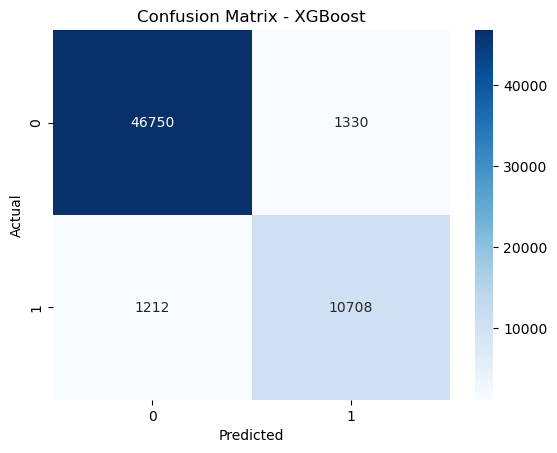

In [28]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.title("Confusion Matrix - XGBoost") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show() 

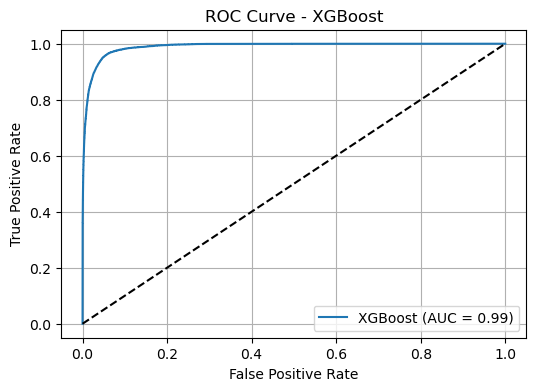

In [29]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb) 
plt.figure(figsize=(6, 4)) 
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_xgb)))
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - XGBoost') 
plt.legend() 
plt.grid(True)
plt.show() 

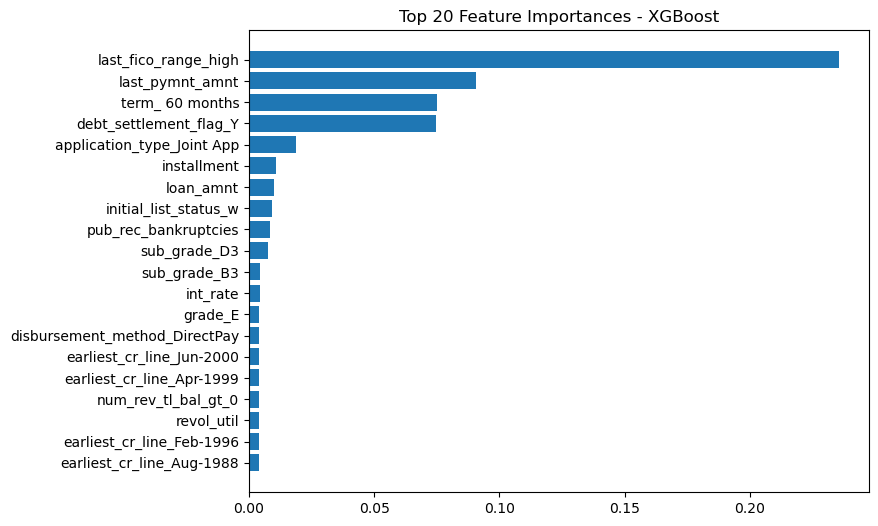

In [30]:
# Plot Feature Importance (Top 20)                                                                       
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:] 

plt.figure(figsize=(8, 6))
plt.barh(range(20), importances[indices], align='center')
plt.yticks(range(20), X_train.columns[indices])
plt.title('Top 20 Feature Importances - XGBoost')
plt.show()                                                                 

In [31]:
# Create a comparison DataFrame summarising performance metrics for Logistic Regression, Random Forest, and XGBoost
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.91, 0.95, 0.96],
    'ROC-AUC': [0.94, 0.979, 0.989],
    'Precision (class 1)': [0.70, 0.89, 0.89],
    'Recall (class 1)': [0.80, 0.84, 0.90],
    'F1-score (class 1)': [0.75, 0.87, 0.89]
})

display(model_comparison)

,Model,Accuracy,ROC-AUC,Precision (class 1),Recall (class 1),F1-score (class 1)
0,Logistic Regression,0.91,0.940,0.70,0.80,0.75
1,Random Forest,0.95,0.979,0.89,0.84,0.87
2,XGBoost,0.96,0.989,0.89,0.90,0.89


In [32]:
# Clean column names 
X_train.columns = [str(col).replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [str(col).replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

In [33]:
# Keep only numeric columns for SHAP
X_train_clean = X_train.select_dtypes(include=[np.number])
X_test_clean = X_test.select_dtypes(include=[np.number])

In [34]:
# Retrain XGBoost model on the cleaned numeric
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_clean, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

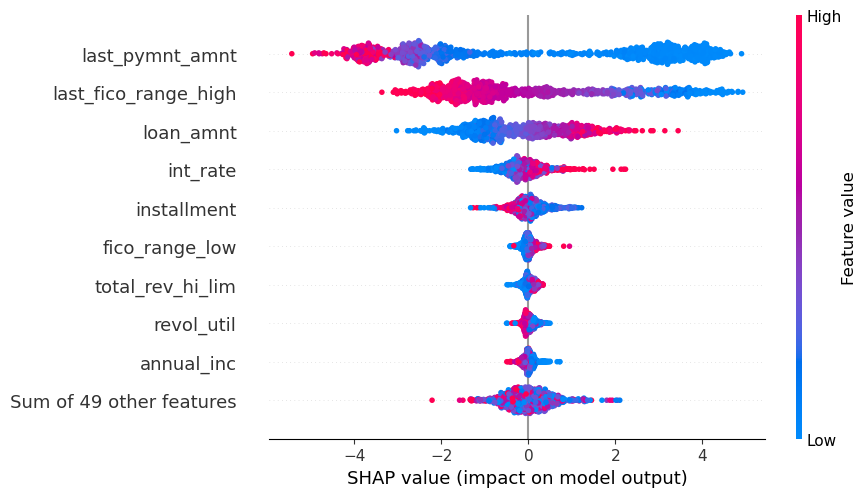

In [35]:
# Sample 1000 rows only for SHAP
X_test_sample = X_test_clean.sample(n=1000, random_state=42)

# Re-run SHAP only on the sample
explainer = shap.Explainer(xgb_model, X_train_clean)
shap_values = explainer(X_test_sample)

# Plot
shap.plots.beeswarm(shap_values)